# Property Masks Viewer

Load the saved per-property masks from `debug_vis/property_masks.csv` and visualize them.

In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("/Users/zd3504phd/Desktop/XAIV")
BENCHMARK_NAME = "vggnet16_benchmark2022_segmented_one_img"
DEBUG_DIR = ROOT / "benchmarks" / BENCHMARK_NAME / "debug_vis"
CSV_PATH = DEBUG_DIR / "property_masks.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(CSV_PATH)

df = pd.read_csv(CSV_PATH)
df["bbox"] = df["bbox"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip() else None
)
df

,image,model,property,tag,is_global,segment_index,eps,k,top1_label,top1_score,segment_score,bbox,mask_path,mask_height,mask_width,mask_true_pixels,mask_total_pixels,mask_true_fraction
0,n01748264_Indian_cobra,vgg16-7,n01748264_Indian_cobra_global_k50176_eps_0.0001,global,True,-1,0.0001,50176,63,0.997599,NaN,None,property_masks/n01748264_Indian_cobra_global_k...,224,224,50176,50176,1.00000
1,n01748264_Indian_cobra,vgg16-7,n01748264_Indian_cobra_fix_mask_seg0_k50176_ep...,fix_mask,False,0,0.0001,50176,63,0.997599,0.947951,"[4, 0, 220, 223]",property_masks/n01748264_Indian_cobra_fix_mask...,224,224,6412,50176,0.12779
2,n01748264_Indian_cobra,vgg16-7,n01748264_Indian_cobra_fix_nonmask_seg0_k50176...,fix_nonmask,False,0,0.0001,50176,63,0.997599,0.947951,"[4, 0, 220, 223]",property_masks/n01748264_Indian_cobra_fix_nonm...,224,224,43764,50176,0.87221


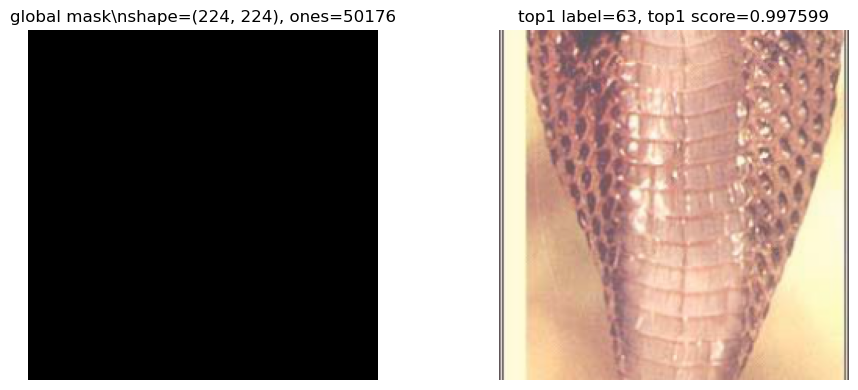

property: n01748264_Indian_cobra_global_k50176_eps_0.0001
mask path: /Users/zd3504phd/Desktop/XAIV/benchmarks/vggnet16_benchmark2022_segmented_one_img/debug_vis/property_masks/n01748264_Indian_cobra_global_k50176_eps_0.0001.npz
segment score: nan
bbox: None


In [2]:
def load_mask(row):
    mask_path = DEBUG_DIR / row["mask_path"]
    mask = np.load(mask_path)["mask"].astype(bool)
    return mask_path, mask

def show_property(row):
    mask_path, mask = load_mask(row)
    image_path = DEBUG_DIR / f"{row['image']}_original.png"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(mask, cmap="gray")
    axes[0].set_title(
        f"{row['tag']} mask\\nshape={mask.shape}, ones={int(mask.sum())}"
    )
    axes[0].axis("off")

    if image_path.exists():
        original = plt.imread(image_path)
        axes[1].imshow(original)
        axes[1].imshow(mask, cmap="Reds", alpha=0.35)
    else:
        axes[1].imshow(mask, cmap="gray")

    axes[1].set_title(
        f"top1 label={int(row['top1_label'])}, top1 score={row['top1_score']:.6f}"
    )
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("property:", row["property"])
    print("mask path:", mask_path)
    print("segment score:", row["segment_score"])
    print("bbox:", row["bbox"])

PROPERTY = None
# Example:
# PROPERTY = "n01748264_Indian_cobra_fix_nonmask_seg0_k50176_eps_0.0001"

selected = df.iloc[0] if PROPERTY is None else df.loc[df["property"].eq(PROPERTY)].iloc[0]
show_property(selected)

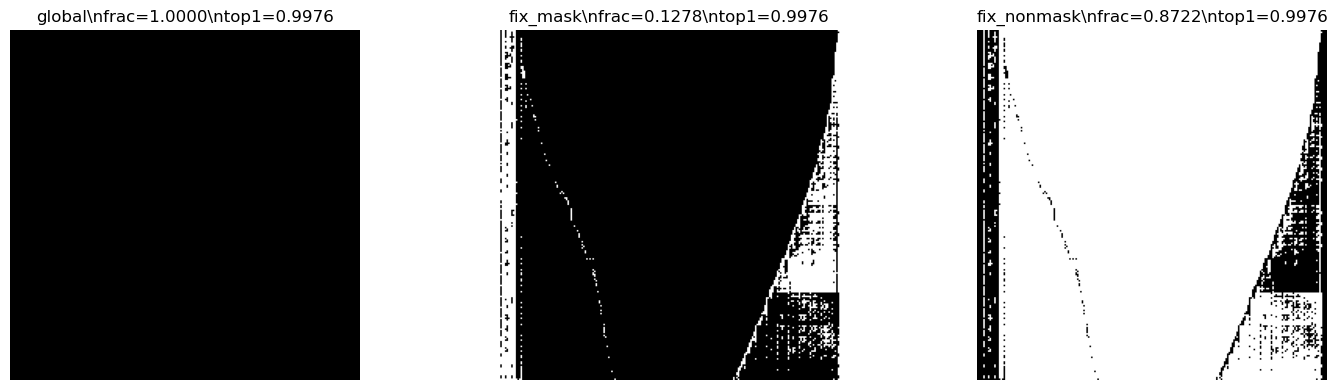

In [3]:
fig, axes = plt.subplots(1, len(df), figsize=(5 * len(df), 4))
axes = np.atleast_1d(axes)

for ax, (_, row) in zip(axes, df.iterrows()):
    _, mask = load_mask(row)
    ax.imshow(mask, cmap="gray")
    ax.set_title(
        f"{row['tag']}\\nfrac={row['mask_true_fraction']:.4f}\\ntop1={row['top1_score']:.4f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

path = "/Users/zd3504phd/Desktop/XAIV/benchmarks/vggnet16_benchmark2022_segmented_one_img/debug_vis/property_masks/n01748264_Indian_cobra_global_k50176_eps_0.0001.npz"

data = np.load(path)

print("Keys:", data.files)

for k in data.files:
    print(k)
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")

Keys: ['mask']
mask
mask: shape=(224, 224), dtype=uint8, min=1, max=1


In [7]:
print(data['mask'])

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
